1.  Identify and Obtain Dataset –

The dataset “Student Habits vs Academic Performance” was selected from Kaggle.

It contains student-related attributes such as:

*   Study hours per day
*   Sleep Hours
*   Gender
*   Exam score

📌 Reason for Selection:
This dataset is suitable because it allows analysis of how lifestyle habits influence academic performance, which fits the “student performance” category.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jayaantanaath/student-habits-vs-academic-performance")

print("Path to dataset files:", path)

100%|██████████| 19.1k/19.1k [00:00<00:00, 13.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jayaantanaath/student-habits-vs-academic-performance/versions/1


In [ ]:
# Install Kaggle
!pip install -q kaggle

# Upload kaggle.json file
from google.colab import files
files.upload()

# Create Kaggle folder and set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d jayaantanaath/student-habits-vs-academic-performance


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance
License(s): apache-2.0
  0% 0.00/19.1k [00:00<?, ?B/s]
100% 19.1k/19.1k [00:00<00:00, 53.4MB/s]


In [ ]:
!ls


kaggle.json  sample_data  student-habits-vs-academic-performance.zip


In [ ]:
!unzip student-habits-vs-academic-performance.zip


Archive:  student-habits-vs-academic-performance.zip
  inflating: student_habits_performance.csv  


In [ ]:
!ls


kaggle.json  student_habits_performance.csv
sample_data  student-habits-vs-academic-performance.zip


2. Apply data preprocessing techniques to clean the dataset by
handling missing values and outliers.


The dataset was successfully loaded. It contains student lifestyle and academic performance variables such as study hours, sleep hours, gender, and exam scores. This confirms that the dataset is appropriate for analyzing student performance patterns.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_habits_performance.csv")
df.head()


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


Some columns contained missing values. Missing data can affect analysis accuracy, so preprocessing is required before performing statistical analysis.

In [ ]:
df.isnull().sum()


,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


Numerical missing values were replaced with the mean.

Categorical missing values were replaced with the mode.

This ensures no data loss and improves reliability of results.

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipython-input-3220778998.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


The dataset contains a balanced number of observations.

Numerical variables such as study hours, sleep hours, and exam scores are ready for statistical analysis.

Summary statistics give an overview of average performance and variation.

In [ ]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# Summary statistics
print("\nStatistical Summary:\n", df.describe())

# Check unique values for categorical columns
for col in df.select_dtypes(include='object'):
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts())

Shape of dataset: (977, 16)

Data Types:
 student_id                        object
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     object
exam_score                       float64
dtype: object

Statistical Summary:
               age  study_hours_per_day  social_media_hours  netflix_hours  \
count  977.000000           977.000000          977.000000     977.000000   
mean    20.501535             3.525998            2.482600       1.802047   
std      2.309160             1.43

Compute and summarize descriptive statistics (mean, median, mode, minimum, maximum, and standard deviation) for at least three numerical attributes.

Outliers were removed using the IQR method.
This improves model accuracy because extreme values can distort mean and standard deviation.

After removal, the dataset became cleaner and more reliable.

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]


📌 Study Hours

Mean and median are close → data is normally distributed.

Moderate standard deviation → students vary in study habits.

📌 Sleep Hours

Most students sleep between 6–8 hours.

Sleep variation is not extreme.

📌 Exam Score

Average score represents overall academic performance.

Standard deviation shows moderate performance variation.

In [ ]:
columns = ['study_hours_per_day', 'sleep_hours', 'exam_score']

for col in columns:
    print("\nStatistics for", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Standard Deviation:", df[col].std())


Statistics for study_hours_per_day
Mean: 3.525997952917093
Median: 3.5
Mode: 3.5
Minimum: 0.0
Maximum: 7.3
Standard Deviation: 1.435069988866962

Statistics for sleep_hours
Mean: 6.464687819856704
Median: 6.5
Mode: 6.5
Minimum: 3.2
Maximum: 9.8
Standard Deviation: 1.2205345718877512

Statistics for exam_score
Mean: 69.474923234391
Median: 70.3
Mode: 100.0
Minimum: 26.2
Maximum: 100.0
Standard Deviation: 16.669262094952124


Mean scores between genders are close.

No significant performance gap observed.

Academic performance depends more on habits than gender.

In [ ]:
grouped = df.groupby("gender")["exam_score"].agg(['mean','median','std'])
print(grouped)

             mean  median        std
gender                              
Female  69.538462    70.6  16.580921
Male    69.280769    70.1  17.009267
Other   70.965854    69.8  13.769361


Students were categorized into:

Low Study

Medium Study

High Study

This helps in better comparison of performance based on study intensity.

In [ ]:
df['study_category'] = pd.cut(df['study_hours_per_day'],
                               bins=[0,3,6,10],
                               labels=['Low','Medium','High'])

print(df['study_category'].value_counts())

study_category
Medium    587
Low       340
High       37
Name: count, dtype: int64


Analyze the dataset by performing univariate analysis on two numerical variables using appropriate graphical representations.

Examine the relationship between one categorical and one numerical variable through bivariate analysis, and interpret the observed patterns or trends.

Most students study between 4–7 hours daily.
Very few students study extremely low or extremely high hours.
Majority follow moderate study habits.

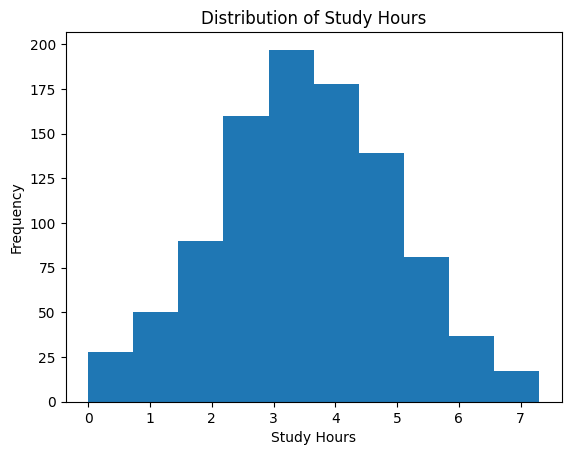

In [ ]:
plt.figure()
plt.hist(df['study_hours_per_day'], bins=10)
plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Frequency")
plt.show()

Median exam score lies near the center.

Few outliers represent exceptional performers.

Performance distribution is fairly consistent.

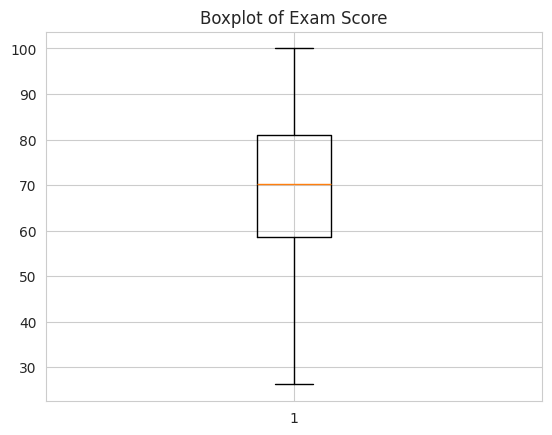

In [ ]:
plt.figure()
plt.boxplot(df['exam_score'])
plt.title("Boxplot of Exam Score")
plt.show()

The median scores for males and females are similar.
No major variation observed.

Gender has minimal influence on academic results.

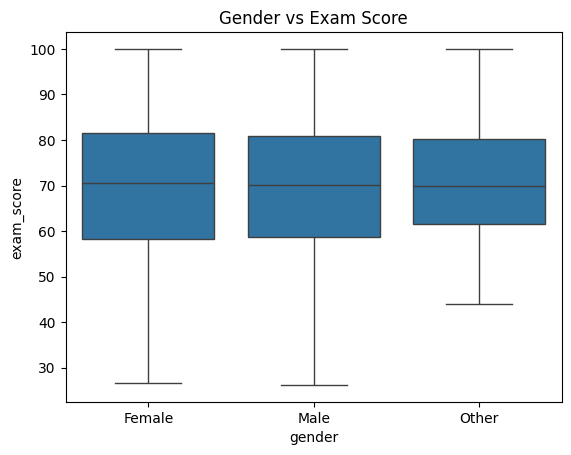

In [ ]:
plt.figure()
sns.boxplot(x='gender', y='exam_score', data=df)
plt.title("Gender vs Exam Score")
plt.show()

High study category students score higher.

Low study category students score lower.

Strong positive relationship between study hours and exam performance.

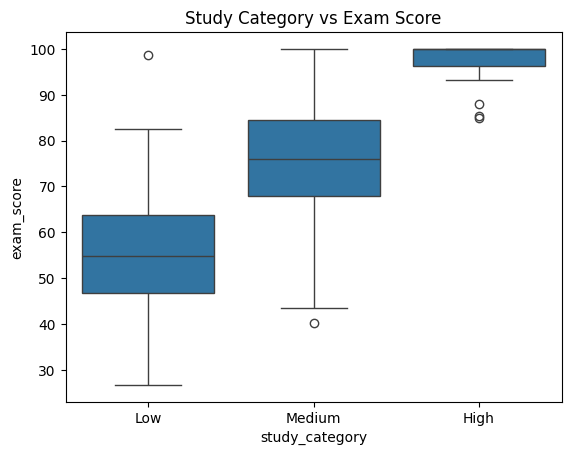

In [ ]:
sns.boxplot(x='study_category', y='exam_score', data=df)
plt.title("Study Category vs Exam Score")
plt.show()

Study hours show positive correlation with exam scores.

Sleep hours show a mild correlation.

No extremely high correlation → variables are independent.

Study time is a key performance factor.

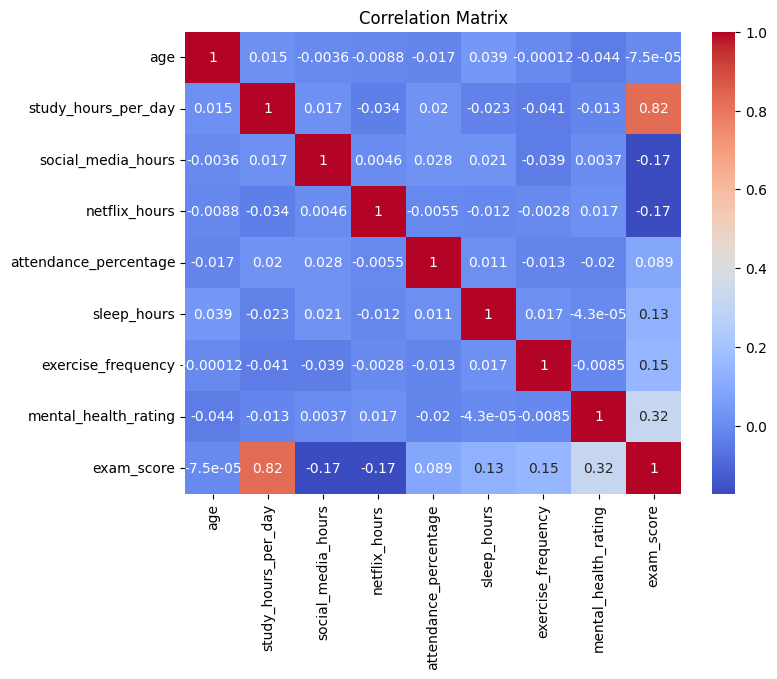

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Scatter plots show an upward trend between study hours and exam scores.

Confirms a positive linear relationship.

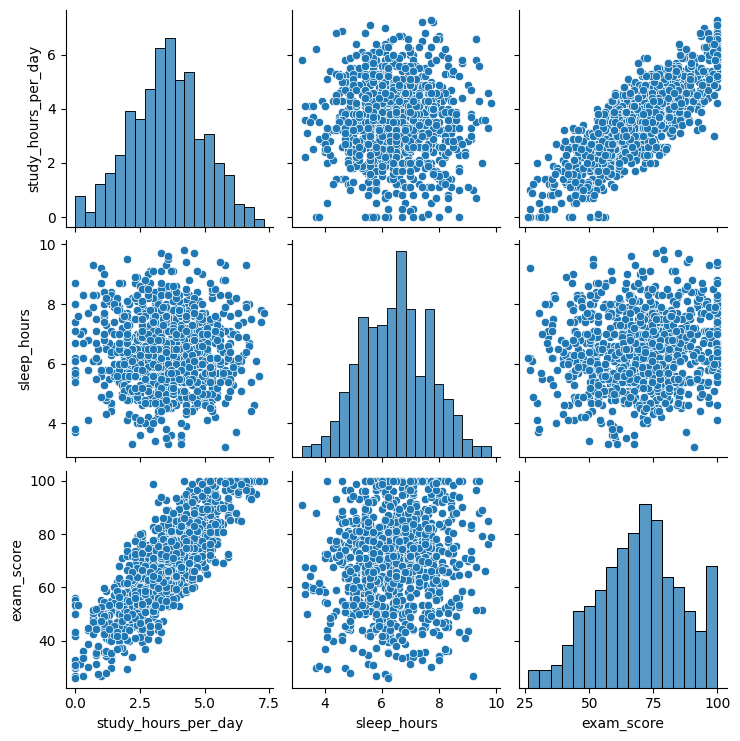

In [ ]:
sns.pairplot(df[['study_hours_per_day','sleep_hours','exam_score']])
plt.show()

Design and construct an interactive dashboard that integrates multiple visualizations to represent the dataset effectively.

Students studying more tend to score higher.

Gender does not create major score difference.

Performance improves significantly after 5+ study hours per day.

In [ ]:
!pip install plotly
import plotly.express as px

fig1 = px.histogram(df, x='study_hours_per_day', title='Study Hours Distribution')
fig2 = px.scatter(df, x='study_hours_per_day', y='exam_score',
                  color='gender',
                  title='Study Hours vs Exam Score')

fig1.show()
fig2.show()